In [31]:
# Install / upgrade dependencies (run once)
!pip3 install -q 'qiskit>=2.1.0' 'qiskit-ibm-runtime>=0.40.1' 'qiskit-aer>=0.17.0' \
    'numpy' 'pandas' 'matplotlib' 'pylatexenc' 'jinja2'


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip


In [3]:
# ─── Imports ───
import os, json, uuid, warnings
from datetime import datetime
from fractions import Fraction
from getpass import getpass
from math import floor, gcd, log

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit.library import QFTGate
from qiskit.transpiler import generate_preset_pass_manager
from qiskit.visualization import plot_histogram

from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import SamplerV2 as Sampler

warnings.filterwarnings("ignore", category=DeprecationWarning)
print("All imports successful.")

All imports successful.


## Configuration

Set experiment parameters here.  All sweeps, paths, and toggles are controlled from this single cell so the notebook is easy to reconfigure without editing experiment code.

In [5]:
# ═══════════════════════════════════════════
# Experiment Configuration
# ═══════════════════════════════════════════

SHOTS          = 1024          # Shots per circuit execution
BACKEND_NAME   = "ibm_marrakesh"   # Preferred backend (None → auto-select least-busy)
RUN_HARDWARE   = True          # Set False to skip real-hardware jobs
OUTPUT_DIR     = "./results"   # Directory for CSV / JSON / PNG artefacts

SEED_TRANSPILER = 42
SEED_SIMULATOR  = 42

# ─── Shor parameters ───
N          = 15
a          = 2
num_target = 4   # floor(log2(N-1)) + 1

# ─── Sweep grids ───
OPT_LEVEL_SWEEP       = [0, 1, 2, 3]       # Transpiler optimisation levels
CONTROL_QUBIT_SWEEP   = [4, 6, 8]           # Control-register sizes (target stays 4)
RESILIENCE_LEVEL_SWEEP = [0, 1]             # SamplerV2 resilience levels
DD_SWEEP              = [False, True]       # Dynamical decoupling on / off

# ─── Success-probability epsilon ───
# If None → 1 / 2^(t+1) per control size t (principled default)
EPSILON = None

# Create output directory
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Output directory: {os.path.abspath(OUTPUT_DIR)}")

Output directory: /Users/destroy/Desktop/MThesis2/Qiskit-v1/results


## Authentication & Backend Selection

Authentication priority:
1. Previously saved IBM Quantum account
2. `apikey.json` in the notebook directory (fallback)
3. Interactive `getpass` prompt

The backend defaults to the value of `BACKEND_NAME`; if it is unavailable or has too few qubits the notebook falls back to the **least-busy** operational backend.

In [6]:
# ─── Authentication ───
service = None

# 1) Try saved account
try:
    service = QiskitRuntimeService()
    print("Loaded saved IBM Quantum account.")
except Exception:
    pass

# 2) Try apikey.json fallback
if service is None:
    for path in ["apikey.json", os.path.join(os.path.dirname(os.path.abspath(".")), "apikey.json")]:
        if os.path.exists(path):
            try:
                with open(path) as f:
                    apidata = json.load(f)
                token = apidata.get("apikey", "")
                if token:
                    QiskitRuntimeService.save_account(
                        channel="ibm_quantum_platform", token=token, overwrite=True
                    )
                    service = QiskitRuntimeService()
                    print(f"Loaded token from {path}")
                    break
            except Exception:
                continue

# 3) Interactive prompt
if service is None:
    token = getpass("Enter your IBM Quantum API token: ")
    QiskitRuntimeService.save_account(
        channel="ibm_quantum_platform", token=token, overwrite=True
    )
    service = QiskitRuntimeService()
    print("Token saved and account loaded.")

# ─── Backend Selection ───
min_qubits = max(CONTROL_QUBIT_SWEEP) + num_target

if BACKEND_NAME:
    try:
        backend = service.backend(BACKEND_NAME)
        if backend.num_qubits < min_qubits:
            print(f"WARNING: {BACKEND_NAME} has only {backend.num_qubits} qubits "
                  f"(need >= {min_qubits}). Falling back to least_busy.")
            backend = service.least_busy(
                operational=True, simulator=False, min_num_qubits=min_qubits
            )
    except Exception as e:
        print(f"WARNING: {BACKEND_NAME} unavailable ({e}). Falling back to least_busy.")
        backend = service.least_busy(
            operational=True, simulator=False, min_num_qubits=min_qubits
        )
else:
    backend = service.least_busy(
        operational=True, simulator=False, min_num_qubits=min_qubits
    )

print(f"Selected backend: {backend.name} ({backend.num_qubits} qubits)")

qiskit_runtime_service.__init__:WARNING:2026-03-01 16:33:43,575: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: Qiskit-GRM. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-03-01 16:33:43,575: Using instance: Qiskit-GRM, plan: open


Loaded token from apikey.json
Selected backend: ibm_marrakesh (156 qubits)


---
## Shor's Order-Finding Circuit Components

The cells below define the hard-coded modular-multiplication gates $M_2 \bmod 15$ and $M_4 \bmod 15$, their controlled versions, a helper that computes $a^{2^k} \bmod N$ by repeated squaring, and the full order-finding circuit with inverse QFT on the control register.

These cells are preserved from the original notebook for reference and visualisation.

In [7]:
def M2mod15():
    """
    M2 (mod 15)
    """
    b = 2
    U = QuantumCircuit(4)

    U.swap(2, 3)
    U.swap(1, 2)
    U.swap(0, 1)

    U = U.to_gate()
    U.name = f"M_{b}"

    return U

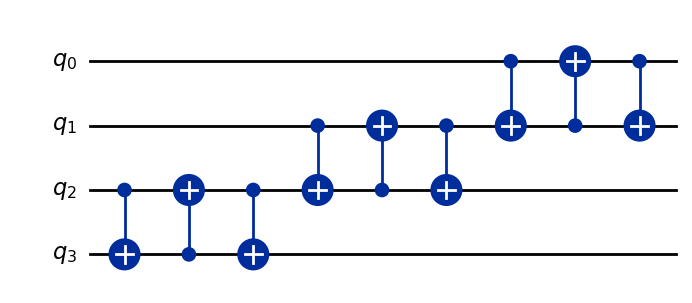

In [8]:
# Get the M2 operator
M2 = M2mod15()

# Add it to a circuit and plot
circ = QuantumCircuit(4)
circ.compose(M2, inplace=True)
circ.decompose(reps=2).draw(output="mpl", fold=-1)

In [9]:
def controlled_M2mod15():
    """
    Controlled M2 (mod 15)
    """
    b = 2
    U = QuantumCircuit(4)

    U.swap(2, 3)
    U.swap(1, 2)
    U.swap(0, 1)

    U = U.to_gate()
    U.name = f"M_{b}"
    c_U = U.control()

    return c_U

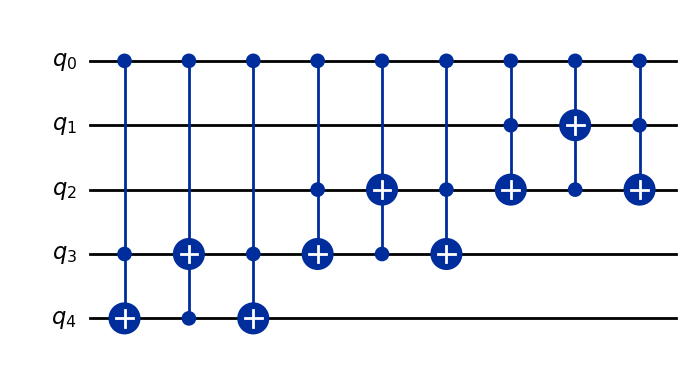

In [10]:
# Get the controlled-M2 operator
controlled_M2 = controlled_M2mod15()

# Add it to a circuit and plot
circ = QuantumCircuit(5)
circ.compose(controlled_M2, inplace=True)
circ.decompose(reps=1).draw(output="mpl", fold=-1)

In [11]:
def a2kmodN(a, k, N):
    """Compute a^{2^k} (mod N) by repeated squaring"""
    for _ in range(k):
        a = int(np.mod(a**2, N))
    return a

In [12]:
k_list = range(8)
b_list = [a2kmodN(2, k, 15) for k in k_list]

print(b_list)

[2, 4, 1, 1, 1, 1, 1, 1]


In [13]:
def M4mod15():
    """
    M4 (mod 15)
    """
    b = 4
    U = QuantumCircuit(4)

    U.swap(1, 3)
    U.swap(0, 2)

    U = U.to_gate()
    U.name = f"M_{b}"

    return U

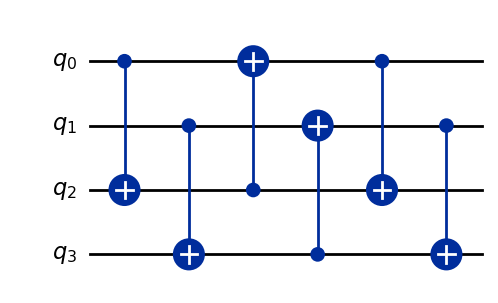

In [14]:
# Get the M4 operator
M4 = M4mod15()

# Add it to a circuit and plot
circ = QuantumCircuit(4)
circ.compose(M4, inplace=True)
circ.decompose(reps=2).draw(output="mpl", fold=-1)

In [15]:
def controlled_M4mod15():
    """
    Controlled M4 (mod 15)
    """
    b = 4
    U = QuantumCircuit(4)

    U.swap(1, 3)
    U.swap(0, 2)

    U = U.to_gate()
    U.name = f"M_{b}"
    c_U = U.control()

    return c_U

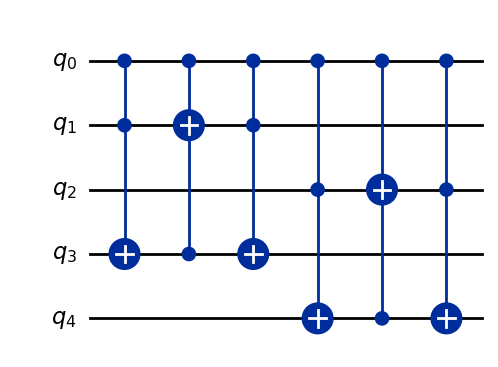

In [16]:
# Get the controlled-M4 operator
controlled_M4 = controlled_M4mod15()

# Add it to a circuit and plot
circ = QuantumCircuit(5)
circ.compose(controlled_M4, inplace=True)
circ.decompose(reps=1).draw(output="mpl", fold=-1)

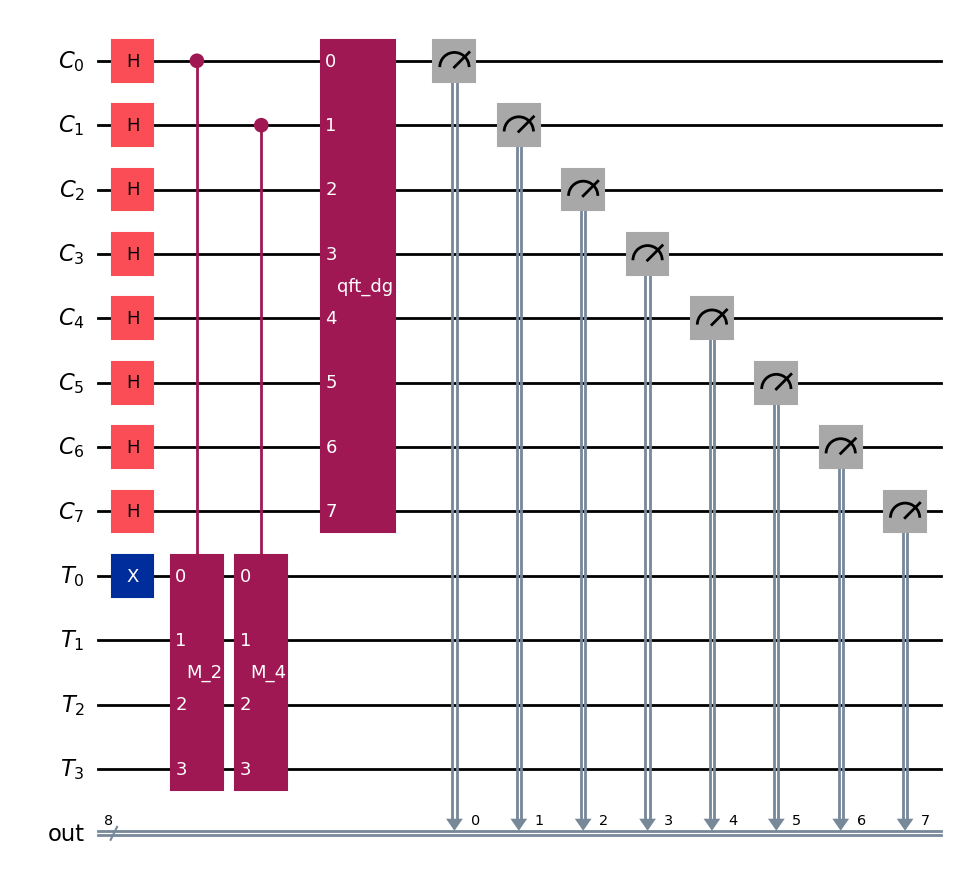

In [17]:
# Order finding problem for N = 15 with a = 2
N = 15
a = 2

# Number of qubits
num_target = floor(log(N - 1, 2)) + 1  # for modular exponentiation operators
num_control = 2 * num_target  # for enough precision of estimation

# List of M_b operators in order
k_list = range(num_control)
b_list = [a2kmodN(2, k, 15) for k in k_list]

# Initialize the circuit
control = QuantumRegister(num_control, name="C")
target = QuantumRegister(num_target, name="T")
output = ClassicalRegister(num_control, name="out")
circuit = QuantumCircuit(control, target, output)

# Initialize the target register to the state |1>
circuit.x(num_control)

# Add the Hadamard gates and controlled versions of the
# multiplication gates
for k, qubit in enumerate(control):
    circuit.h(k)
    b = b_list[k]
    if b == 2:
        circuit.compose(
            M2mod15().control(), qubits=[qubit] + list(target), inplace=True
        )
    elif b == 4:
        circuit.compose(
            M4mod15().control(), qubits=[qubit] + list(target), inplace=True
        )
    else:
        continue  # M1 is the identity operator

# Apply the inverse QFT to the control register
circuit.compose(QFTGate(num_control).inverse(), qubits=control, inplace=True)

# Measure the control register
circuit.measure(control, output)

circuit.draw("mpl", fold=-1)

---
## Experiment Helper Functions

| Function | Purpose |
|---|---|
| `build_shor_circuit(num_control, ...)` | Build the order-finding circuit for configurable control-register size |
| `transpile_for_backend(circuit, backend, opt_level, ...)` | Transpile and return 2-qubit depth / gate count |
| `run_ideal(circuit, shots)` | Noiseless Aer simulation |
| `run_noisy(circuit, backend, shots)` | Noisy Aer simulation (device noise model or generic fallback) |
| `run_hardware(transpiled, backend, shots, ...)` | Submit to IBM hardware via SamplerV2 |
| `compute_metrics(dist, ideal_dist, noisy_dist, num_control, epsilon)` | TVD, success probability on expected Shor peaks |

In [18]:
def build_shor_circuit(num_control, num_target=4, a=2, N=15):
    """
    Build the Shor order-finding circuit.

    Parameters
    ----------
    num_control : int   Number of control (phase-estimation) qubits.
    num_target  : int   Number of target (modular-arithmetic) qubits.
    a           : int   Base for order finding.
    N           : int   Modulus.

    Returns
    -------
    QuantumCircuit with registers C (control), T (target), out (classical).
    """
    k_list = range(num_control)
    b_list = [a2kmodN(a, k, N) for k in k_list]

    control = QuantumRegister(num_control, name="C")
    target  = QuantumRegister(num_target, name="T")
    output  = ClassicalRegister(num_control, name="out")
    qc      = QuantumCircuit(control, target, output)

    # Initialise target register to |1>
    qc.x(num_control)

    for k, qubit in enumerate(control):
        qc.h(k)
        b = b_list[k]
        if b == 2:
            qc.compose(M2mod15().control(),
                       qubits=[qubit] + list(target), inplace=True)
        elif b == 4:
            qc.compose(M4mod15().control(),
                       qubits=[qubit] + list(target), inplace=True)
        # b == 1 is identity — skip

    # Inverse QFT on control register
    qc.compose(QFTGate(num_control).inverse(), qubits=control, inplace=True)

    # Measure control register
    qc.measure(control, output)

    return qc

# Quick sanity check
_qc = build_shor_circuit(num_control=8, num_target=4)
print(f"build_shor_circuit: {_qc.num_qubits} qubits, {_qc.num_clbits} classical bits")

build_shor_circuit: 12 qubits, 8 classical bits


In [19]:
def transpile_for_backend(circuit, backend, optimization_level, seed=SEED_TRANSPILER):
    """
    Transpile *circuit* for *backend* and return (transpiled_circuit, metrics_dict).
    """
    pm = generate_preset_pass_manager(
        optimization_level=optimization_level,
        backend=backend,
        seed_transpiler=seed,
    )
    tc = pm.run(circuit)

    metrics = {
        "depth_2q":    tc.depth(lambda x: x.operation.num_qubits == 2),
        "count_2q":    tc.size(lambda x: x.operation.num_qubits == 2),
        "total_depth": tc.depth(),
    }
    return tc, metrics

In [20]:
def run_ideal(circuit, shots=100_000, seed=SEED_SIMULATOR):
    """
    Tier A — ideal (noiseless) simulation via StatevectorSampler.

    Uses Qiskit's built-in StatevectorSampler for exact noiseless sampling.

    Returns
    -------
    dict  {bitstring: probability}
    """
    from qiskit.primitives import StatevectorSampler

    sampler = StatevectorSampler(seed=seed)
    job     = sampler.run([circuit], shots=shots)
    result  = job.result()[0]

    counts = result.data.out.get_counts()
    total  = sum(counts.values())
    return {k: v / total for k, v in counts.items()}

In [21]:
def run_noisy(circuit, backend, shots=SHOTS, seed=SEED_SIMULATOR):
    """
    Tier B — noisy simulation via AerSimulator.

    Attempts to build a noise model from the real backend.
    Falls back to a simple depolarising model if that fails.

    Returns
    -------
    dict  {bitstring: probability}   (or empty dict on total failure)
    """
    from qiskit_aer import AerSimulator
    from qiskit_aer.noise import NoiseModel, depolarizing_error

    noise_model = None
    noise_source = "none"

    # Attempt 1: real-backend noise model
    try:
        noise_model = NoiseModel.from_backend(backend)
        noise_source = "backend"
    except Exception as e:
        print(f"  Could not build noise model from backend: {e}")

    # Attempt 2: generic depolarising fallback
    if noise_model is None or len(noise_model.to_dict().get("errors", [])) == 0:
        try:
            noise_model = NoiseModel()
            # 1-qubit depolarising error ~0.1 %
            err_1q = depolarizing_error(0.001, 1)
            # 2-qubit depolarising error ~1 %
            err_2q = depolarizing_error(0.01, 2)
            noise_model.add_all_qubit_quantum_error(err_1q, ["u1", "u2", "u3", "sx", "x", "rz"])
            noise_model.add_all_qubit_quantum_error(err_2q, ["cx", "ecr", "cz"])
            noise_source = "generic-depolarising"
            print(f"  Using generic depolarising noise model.")
        except Exception as e2:
            print(f"  Noisy simulation unavailable: {e2}")
            return {}

    sim = AerSimulator(noise_model=noise_model, seed_simulator=seed)
    pm  = generate_preset_pass_manager(optimization_level=0, backend=sim)
    tc  = pm.run(circuit)

    # Use AerSimulator.run() directly (reliable across Aer versions)
    result = sim.run(tc, shots=shots).result()
    counts = result.get_counts()
    total  = sum(counts.values())
    dist   = {k: v / total for k, v in counts.items()}
    return dist

In [22]:
def run_hardware(transpiled_circuit, backend, shots=SHOTS,
                 resilience_level=0, dd_enable=False):
    """
    Tier C — real IBM hardware via SamplerV2.

    Parameters
    ----------
    transpiled_circuit : QuantumCircuit  (already transpiled for backend)
    backend            : IBMBackend
    shots              : int
    resilience_level   : int             0 or 1
    dd_enable          : bool            enable dynamical decoupling

    Returns
    -------
    (distribution_dict, job_id_str)
    """
    sampler = Sampler(mode=backend)

    # ── Runtime options ──
    try:
        sampler.options.default_shots = shots
    except Exception:
        pass

    try:
        sampler.options.resilience_level = resilience_level
    except Exception:
        pass

    if dd_enable:
        try:
            sampler.options.dynamical_decoupling.enable = True
            sampler.options.dynamical_decoupling.sequence_type = "XpXm"
        except Exception:
            pass

    try:
        sampler.options.twirling.enable_gates = True
    except Exception:
        pass

    job = sampler.run([transpiled_circuit], shots=shots)
    job_id = job.job_id()
    print(f"  Submitted job {job_id} on {backend.name}")

    result = job.result()[0]
    counts = result.data.out.get_counts()
    total  = sum(counts.values())
    dist   = {k: v / total for k, v in counts.items()}

    return dist, job_id

In [23]:
def compute_metrics(dist, ideal_dist, noisy_dist, num_control,
                    a=2, N=15, epsilon=None):
    """
    Compute thesis metrics for one experiment run.

    Returns
    -------
    dict with keys: tvd_vs_ideal, tvd_vs_noisy, tvd_noisy_vs_ideal,
                    success_prob, expected_phases
    """
    # ── Total Variation Distance ──
    def tvd(p, q):
        all_keys = set(p) | set(q)
        return 0.5 * sum(abs(p.get(k, 0.0) - q.get(k, 0.0)) for k in all_keys)

    tvd_vs_ideal     = tvd(dist, ideal_dist)
    tvd_vs_noisy     = tvd(dist, noisy_dist) if noisy_dist else None
    tvd_noisy_ideal  = tvd(noisy_dist, ideal_dist) if noisy_dist else None

    # ── Success probability on expected Shor peaks ──
    # For a=2, N=15 the true order is r=4.
    # Expected phases: k/r for k in {0,1,2,3} → {0, 0.25, 0.5, 0.75}
    r = 4
    expected_phases = [k / r for k in range(r)]

    if epsilon is None:
        epsilon = 1.0 / (2 ** (num_control + 1))

    success_mass = 0.0
    for bitstring, prob in dist.items():
        measured_phase = int(bitstring, 2) / (2 ** num_control)
        for ep in expected_phases:
            # Handle wrap-around at 0/1 boundary
            diff = abs(measured_phase - ep)
            diff = min(diff, 1.0 - diff)
            if diff <= epsilon:
                success_mass += prob
                break

    return {
        "tvd_vs_ideal":       round(tvd_vs_ideal, 6),
        "tvd_vs_noisy":       round(tvd_vs_noisy, 6) if tvd_vs_noisy is not None else None,
        "tvd_noisy_vs_ideal": round(tvd_noisy_ideal, 6) if tvd_noisy_ideal is not None else None,
        "success_prob":       round(success_mass, 6),
        "expected_phases":    expected_phases,
        "epsilon":            epsilon,
    }

---
## Benchmarking Tiers

| Tier | Description |
|------|-------------|
| **A — Ideal** | Noiseless Aer simulation (100k shots). Establishes the theoretical baseline. |
| **B — Noisy** | Aer simulation with a device-derived noise model (or generic depolarising fallback). Models the main error channels without queue wait. |
| **C — Hardware** | Real IBM Quantum hardware via SamplerV2 with configurable resilience and dynamical decoupling. |

### Metrics

| Metric | Meaning |
|--------|---------|
| **TVD** (Total Variation Distance) | $\text{TVD}(P,Q) = \frac{1}{2}\sum_x |P(x)-Q(x)|$.  Ranges 0 (identical) to 1 (fully disjoint). |
| **Success probability** | Sum of probability mass within an $\varepsilon$-window of each expected Shor peak phase $\{0, 1/4, 1/2, 3/4\}$. |

## Experiment Sweeps

The loop below runs the **same** Shor circuit through every combination of:

| Axis | Values | What it tests |
|------|--------|---------------|
| Optimisation level | 0, 1, 2, 3 | Compiler aggressiveness (circuit depth vs fidelity) |
| Control-qubit precision | 4, 6, 8 | Phase-estimation precision (higher → more qubits, deeper circuit) |
| Resilience level | 0, 1 | IBM error-mitigation overhead (SamplerV2 option) |
| Dynamical decoupling | Off, On | Idle-qubit decoherence suppression |

Every configuration is run on all three tiers (ideal / noisy / hardware) and the results are stored in a DataFrame for subsequent analysis.

In [24]:
# ═══════════════════════════════════════════
# Run All Experiments
# ═══════════════════════════════════════════

all_results = []   # list of dicts → DataFrame later
all_distributions = {}  # run_id → {tier: distribution}
run_counter = 0

for nc in CONTROL_QUBIT_SWEEP:
    # 1) Build circuit
    qc = build_shor_circuit(num_control=nc, num_target=num_target, a=a, N=N)
    print(f"\n{'='*60}")
    print(f"Control qubits = {nc}  (total qubits = {nc + num_target})")
    print(f"{'='*60}")

    # 2) Ideal distribution (computed once per control size)
    print("  [Tier A] Ideal simulation …")
    ideal_dist = run_ideal(qc, shots=100_000, seed=SEED_SIMULATOR)
    print(f"    → {len(ideal_dist)} unique bitstrings")

    # 3) Noisy distribution (once per control size)
    print("  [Tier B] Noisy simulation …")
    noisy_dist = run_noisy(qc, backend, shots=SHOTS, seed=SEED_SIMULATOR)
    if noisy_dist:
        print(f"    → {len(noisy_dist)} unique bitstrings")
    else:
        print(f"    → skipped (no noise model available)")

    for opt_level in OPT_LEVEL_SWEEP:
        # 4) Transpile
        tc, t_metrics = transpile_for_backend(qc, backend, opt_level, seed=SEED_TRANSPILER)
        print(f"\n  opt_level={opt_level}  2q-depth={t_metrics['depth_2q']}  2q-count={t_metrics['count_2q']}")

        for res_level in RESILIENCE_LEVEL_SWEEP:
            for dd in DD_SWEEP:
                run_counter += 1
                run_id = f"run-{run_counter:04d}"
                ts = datetime.utcnow().isoformat() + "Z"

                row = {
                    "run_id": run_id,
                    "timestamp": ts,
                    "num_control": nc,
                    "num_target": num_target,
                    "opt_level": opt_level,
                    "resilience_level": res_level,
                    "dd_enable": dd,
                    "shots": SHOTS,
                    "backend": backend.name,
                    "depth_2q": t_metrics["depth_2q"],
                    "count_2q": t_metrics["count_2q"],
                    "total_depth": t_metrics["total_depth"],
                }

                eps = EPSILON if EPSILON else 1.0 / (2 ** (nc + 1))

                # Ideal metrics (same ideal_dist reused)
                ideal_metrics = compute_metrics(
                    ideal_dist, ideal_dist, noisy_dist, nc, a=a, N=N, epsilon=eps
                )
                row["ideal_success_prob"] = ideal_metrics["success_prob"]

                # Noisy metrics
                if noisy_dist:
                    noisy_metrics = compute_metrics(
                        noisy_dist, ideal_dist, noisy_dist, nc, a=a, N=N, epsilon=eps
                    )
                    row["noisy_success_prob"] = noisy_metrics["success_prob"]
                    row["tvd_noisy_vs_ideal"] = noisy_metrics["tvd_vs_ideal"]
                else:
                    row["noisy_success_prob"] = None
                    row["tvd_noisy_vs_ideal"] = None

                # Hardware run
                if RUN_HARDWARE:
                    tag = f"res={res_level} dd={'ON' if dd else 'OFF'}"
                    print(f"    [{run_id}] Hardware: opt={opt_level} {tag} …")
                    try:
                        hw_dist, job_id = run_hardware(
                            tc, backend, shots=SHOTS,
                            resilience_level=res_level, dd_enable=dd,
                        )
                        hw_metrics = compute_metrics(
                            hw_dist, ideal_dist, noisy_dist, nc, a=a, N=N, epsilon=eps
                        )
                        row["hw_success_prob"]    = hw_metrics["success_prob"]
                        row["tvd_hw_vs_ideal"]    = hw_metrics["tvd_vs_ideal"]
                        row["tvd_hw_vs_noisy"]    = hw_metrics["tvd_vs_noisy"]
                        row["job_id"]             = job_id
                        all_distributions[run_id] = {
                            "ideal": ideal_dist,
                            "noisy": noisy_dist,
                            "hardware": hw_dist,
                        }
                        print(f"      success_prob={hw_metrics['success_prob']:.4f}  "
                              f"tvd_hw_ideal={hw_metrics['tvd_vs_ideal']:.4f}")
                    except Exception as e:
                        print(f"      ERROR: {e}")
                        row["hw_success_prob"] = None
                        row["tvd_hw_vs_ideal"] = None
                        row["tvd_hw_vs_noisy"] = None
                        row["job_id"]          = None
                else:
                    row["hw_success_prob"] = None
                    row["tvd_hw_vs_ideal"] = None
                    row["tvd_hw_vs_noisy"] = None
                    row["job_id"]          = None

                all_results.append(row)

print(f"\nDone — {len(all_results)} experiment rows collected.")


Control qubits = 4  (total qubits = 8)
  [Tier A] Ideal simulation …
    → 4 unique bitstrings
  [Tier B] Noisy simulation …
    → 13 unique bitstrings

  opt_level=0  2q-depth=218  2q-count=249
    [run-0001] Hardware: opt=0 res=0 dd=OFF …
  Submitted job d6i34mm33pjc73dka450 on ibm_marrakesh
      success_prob=0.3965  tvd_hw_ideal=0.6035
    [run-0002] Hardware: opt=0 res=0 dd=ON …
  Submitted job d6i3594mmeis739pqmig on ibm_marrakesh
      success_prob=0.7002  tvd_hw_ideal=0.2998
    [run-0003] Hardware: opt=0 res=1 dd=OFF …
  Submitted job d6i35c860irc7392rk1g on ibm_marrakesh
      success_prob=0.3867  tvd_hw_ideal=0.6133
    [run-0004] Hardware: opt=0 res=1 dd=ON …
  Submitted job d6i35f633pjc73dka530 on ibm_marrakesh
      success_prob=0.6582  tvd_hw_ideal=0.3418

  opt_level=1  2q-depth=188  2q-count=198
    [run-0005] Hardware: opt=1 res=0 dd=OFF …
  Submitted job d6i35im33pjc73dka56g on ibm_marrakesh
      success_prob=0.7793  tvd_hw_ideal=0.2207
    [run-0006] Hardware: opt

---
## Results & Analysis

In [25]:
# ─── Build DataFrame ───
df = pd.DataFrame(all_results)
display(df)

# ─── Export CSV ───
csv_path = os.path.join(OUTPUT_DIR, "results.csv")
df.to_csv(csv_path, index=False)
print(f"Saved {csv_path}")

# ─── Export JSON (includes raw distributions + metadata) ───
json_payload = {
    "created": datetime.utcnow().isoformat() + "Z",
    "backend": backend.name,
    "shor_params": {"a": a, "N": N},
    "runs": all_results,
    "distributions": {
        rid: {tier: dist for tier, dist in tiers.items()}
        for rid, tiers in all_distributions.items()
    },
}
json_path = os.path.join(OUTPUT_DIR, "results.json")
with open(json_path, "w") as f:
    json.dump(json_payload, f, indent=2, default=str)
print(f"Saved {json_path}")

,run_id,timestamp,num_control,num_target,opt_level,resilience_level,dd_enable,shots,backend,depth_2q,count_2q,total_depth,ideal_success_prob,noisy_success_prob,tvd_noisy_vs_ideal,hw_success_prob,tvd_hw_vs_ideal,tvd_hw_vs_noisy,job_id
0,run-0001,2026-03-01T12:34:32.454569Z,4,4,0,0,False,1024,ibm_marrakesh,218,249,1018,1.0,0.946289,0.056737,0.396484,0.603516,0.549805,d6i34mm33pjc73dka450
1,run-0002,2026-03-01T12:35:47.624660Z,4,4,0,0,True,1024,ibm_marrakesh,218,249,1018,1.0,0.946289,0.056737,0.700195,0.299805,0.246094,d6i3594mmeis739pqmig
2,run-0003,2026-03-01T12:36:00.768683Z,4,4,0,1,False,1024,ibm_marrakesh,218,249,1018,1.0,0.946289,0.056737,0.386719,0.613281,0.559570,d6i35c860irc7392rk1g
3,run-0004,2026-03-01T12:36:10.343980Z,4,4,0,1,True,1024,ibm_marrakesh,218,249,1018,1.0,0.946289,0.056737,0.658203,0.341797,0.288086,d6i35f633pjc73dka530
4,run-0005,2026-03-01T12:36:24.751964Z,4,4,1,0,False,1024,ibm_marrakesh,188,198,668,1.0,0.946289,0.056737,0.779297,0.220703,0.166992,d6i35im33pjc73dka56g
5,run-0006,2026-03-01T12:36:34.717533Z,4,4,1,0,True,1024,ibm_marrakesh,188,198,668,1.0,0.946289,0.056737,0.695312,0.304688,0.250977,d6i35ku33pjc73dka590
6,run-0007,2026-03-01T12:36:48.073863Z,4,4,1,1,False,1024,ibm_marrakesh,188,198,668,1.0,0.946289,0.056737,0.754883,0.245117,0.191406,d6i35o860irc7392rkeg
7,run-0008,2026-03-01T12:37:00.031582Z,4,4,1,1,True,1024,ibm_marrakesh,188,198,668,1.0,0.946289,0.056737,0.678711,0.321289,0.267578,d6i35rkgmsgc73btdamg
8,run-0009,2026-03-01T12:37:14.192345Z,4,4,2,0,False,1024,ibm_marrakesh,155,164,547,1.0,0.946289,0.056737,0.883789,0.154817,0.126953,d6i35usmmeis739pqnb0
9,run-0010,2026-03-01T12:37:23.024460Z,4,4,2,0,True,1024,ibm_marrakesh,155,164,547,1.0,0.946289,0.056737,0.793945,0.206055,0.177734,d6i3614gmsgc73btdau0


Saved ./results/results.csv
Saved ./results/results.json


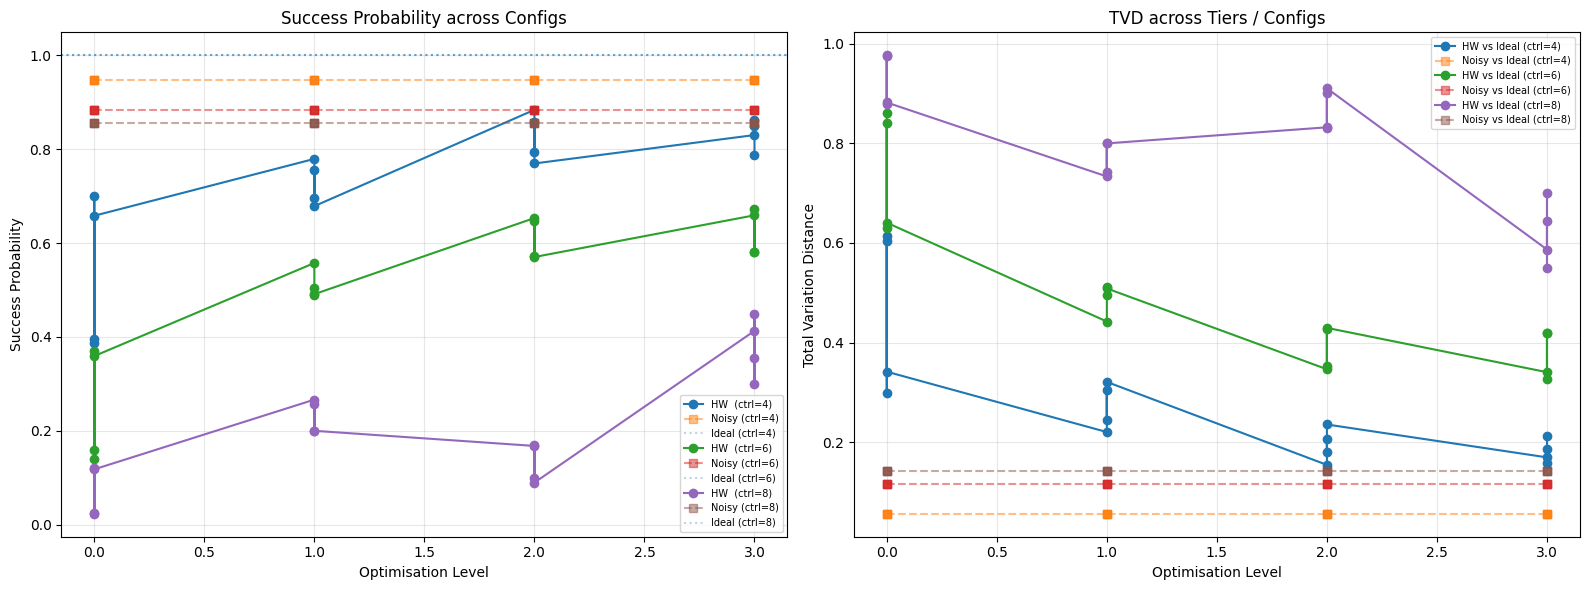

Saved ./results/success_prob_and_tvd.png


In [26]:
# ═══════════════════════════════════════════
# Plots  (all from computed data — nothing invented)
# ═══════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ─── Plot 1: Success Probability ───
ax = axes[0]
for nc in CONTROL_QUBIT_SWEEP:
    sub = df[df["num_control"] == nc]
    if sub["hw_success_prob"].notna().any():
        ax.plot(sub["opt_level"], sub["hw_success_prob"],
                marker="o", label=f"HW  (ctrl={nc})")
    if sub["noisy_success_prob"].notna().any():
        ax.plot(sub["opt_level"], sub["noisy_success_prob"],
                marker="s", linestyle="--", alpha=0.5, label=f"Noisy (ctrl={nc})")
    if sub["ideal_success_prob"].notna().any():
        ax.axhline(sub["ideal_success_prob"].iloc[0],
                   linestyle=":", alpha=0.3, label=f"Ideal (ctrl={nc})")
ax.set_xlabel("Optimisation Level")
ax.set_ylabel("Success Probability")
ax.set_title("Success Probability across Configs")
ax.legend(fontsize=7, loc="best")
ax.grid(True, alpha=0.3)

# ─── Plot 2: TVD ───
ax = axes[1]
for nc in CONTROL_QUBIT_SWEEP:
    sub = df[df["num_control"] == nc]
    if sub["tvd_hw_vs_ideal"].notna().any():
        ax.plot(sub["opt_level"], sub["tvd_hw_vs_ideal"],
                marker="o", label=f"HW vs Ideal (ctrl={nc})")
    if sub["tvd_noisy_vs_ideal"].notna().any():
        ax.plot(sub["opt_level"], sub["tvd_noisy_vs_ideal"],
                marker="s", linestyle="--", alpha=0.5, label=f"Noisy vs Ideal (ctrl={nc})")
ax.set_xlabel("Optimisation Level")
ax.set_ylabel("Total Variation Distance")
ax.set_title("TVD across Tiers / Configs")
ax.legend(fontsize=7, loc="best")
ax.grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "success_prob_and_tvd.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved {os.path.join(OUTPUT_DIR, 'success_prob_and_tvd.png')}")

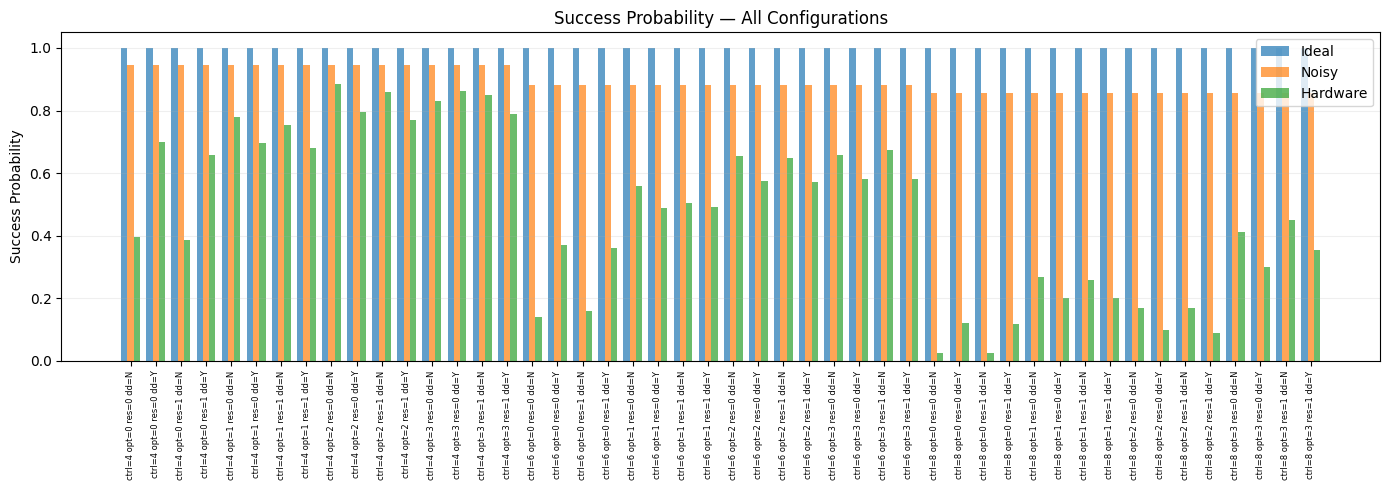

Saved ./results/success_prob_bar.png


In [27]:
# ─── Bar chart: Success probability grouped by config ───
fig, ax = plt.subplots(figsize=(14, 5))

labels = []
hw_vals = []
noisy_vals = []
ideal_vals = []

for _, row in df.iterrows():
    tag = (f"ctrl={row['num_control']} opt={row['opt_level']} "
           f"res={row['resilience_level']} dd={'Y' if row['dd_enable'] else 'N'}")
    labels.append(tag)
    hw_vals.append(row.get("hw_success_prob") or 0)
    noisy_vals.append(row.get("noisy_success_prob") or 0)
    ideal_vals.append(row.get("ideal_success_prob") or 0)

x = np.arange(len(labels))
w = 0.25
ax.bar(x - w, ideal_vals, w, label="Ideal", alpha=0.7)
ax.bar(x,     noisy_vals, w, label="Noisy", alpha=0.7)
ax.bar(x + w, hw_vals,    w, label="Hardware", alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=90, fontsize=6)
ax.set_ylabel("Success Probability")
ax.set_title("Success Probability — All Configurations")
ax.legend()
ax.grid(True, alpha=0.2, axis="y")
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "success_prob_bar.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved {os.path.join(OUTPUT_DIR, 'success_prob_bar.png')}")

In [34]:
# ─── Summary Table ───
summary_cols = [
    "run_id", "num_control", "opt_level", "resilience_level", "dd_enable",
    "depth_2q", "count_2q", "ideal_success_prob", "noisy_success_prob",
    "hw_success_prob", "tvd_hw_vs_ideal", "tvd_noisy_vs_ideal", "job_id",
]
existing_cols = [c for c in summary_cols if c in df.columns]
try:
    display(df[existing_cols].style.format(precision=4, na_rep="—").set_caption(
        f"Shor(N={N}, a={a}) — Experiment Summary"))
except AttributeError:
    # jinja2 not installed — fall back to plain DataFrame display
    display(df[existing_cols])

,run_id,num_control,opt_level,resilience_level,dd_enable,depth_2q,count_2q,ideal_success_prob,noisy_success_prob,hw_success_prob,tvd_hw_vs_ideal,tvd_noisy_vs_ideal,job_id
0,run-0001,4,0,0,False,218,249,1.0000,0.9463,0.3965,0.6035,0.0567,d6i34mm33pjc73dka450
1,run-0002,4,0,0,True,218,249,1.0000,0.9463,0.7002,0.2998,0.0567,d6i3594mmeis739pqmig
2,run-0003,4,0,1,False,218,249,1.0000,0.9463,0.3867,0.6133,0.0567,d6i35c860irc7392rk1g
3,run-0004,4,0,1,True,218,249,1.0000,0.9463,0.6582,0.3418,0.0567,d6i35f633pjc73dka530
4,run-0005,4,1,0,False,188,198,1.0000,0.9463,0.7793,0.2207,0.0567,d6i35im33pjc73dka56g
5,run-0006,4,1,0,True,188,198,1.0000,0.9463,0.6953,0.3047,0.0567,d6i35ku33pjc73dka590
6,run-0007,4,1,1,False,188,198,1.0000,0.9463,0.7549,0.2451,0.0567,d6i35o860irc7392rkeg
7,run-0008,4,1,1,True,188,198,1.0000,0.9463,0.6787,0.3213,0.0567,d6i35rkgmsgc73btdamg
8,run-0009,4,2,0,False,155,164,1.0000,0.9463,0.8838,0.1548,0.0567,d6i35usmmeis739pqnb0
9,run-0010,4,2,0,True,155,164,1.0000,0.9463,0.7939,0.2061,0.0567,d6i3614gmsgc73btdau0


---
## Factor Extraction (Shor's Algorithm Demo)

Using the **best hardware run** (highest success probability), extract candidate factors of $N = 15$ from the measured control-register bitstrings.

The algorithm:
1. Filter bitstrings keeping only those above half the peak count.
2. Convert each bitstring to a phase $\theta = j / 2^t$.
3. Use continued fractions to estimate the order $r$.
4. Compute $\gcd(a^{r/2} \pm 1,\; N)$ to find non-trivial factors.

In [35]:
# ─── Factor Extraction from Best Hardware Run ───

# Find the run with the best hardware success probability
if RUN_HARDWARE and df["hw_success_prob"].notna().any():
    best_row = df.loc[df["hw_success_prob"].idxmax()]
    best_id  = best_row["run_id"]
    best_nc  = int(best_row["num_control"])
    hw_dist  = all_distributions.get(best_id, {}).get("hardware", {})

    if hw_dist:
        # Convert probabilities → pseudo-counts for filtering
        counts = {k: int(v * SHOTS) for k, v in hw_dist.items()}

        # Keep only above half-max
        threshold = max(counts.values()) / 2
        counts_keep = {k: v for k, v in counts.items() if v > threshold}
        print(f"Best run: {best_id}  (ctrl={best_nc}, "
              f"success_prob={best_row['hw_success_prob']:.4f})")
        print(f"Peaks above threshold: {counts_keep}\n")

        FACTOR_FOUND = False
        for i, bitstring in enumerate(counts_keep):
            print(f"ATTEMPT {i}:")
            decimal = int(bitstring, 2)
            phase = decimal / (2 ** best_nc)
            print(f"  Phase: theta = {phase:.6f}")

            frac = Fraction(phase).limit_denominator(N)
            r = frac.denominator
            print(f"  Estimated order r = {r}")

            if phase != 0 and r % 2 == 0:
                x = pow(a, r // 2, N) - 1
                d = gcd(x, N)
                if d > 1 and d != N:
                    FACTOR_FOUND = True
                    print(f"  *** Non-trivial factor found: {d} ***")
                    print(f"  {N} = {d} x {N // d}")
                    break

        if not FACTOR_FOUND:
            print("No non-trivial factor found from the filtered peaks.")
    else:
        print("No hardware distribution available for factor extraction.")
else:
    print("Hardware runs were disabled or produced no results. "
          "Set RUN_HARDWARE = True and re-run the experiment sweep.")

Best run: run-0009  (ctrl=4, success_prob=0.8838)
Peaks above threshold: {'1000': 228, '0000': 295, '0100': 200, '1100': 182}

ATTEMPT 0:
  Phase: theta = 0.500000
  Estimated order r = 2
ATTEMPT 1:
  Phase: theta = 0.000000
  Estimated order r = 1
ATTEMPT 2:
  Phase: theta = 0.250000
  Estimated order r = 4
  *** Non-trivial factor found: 3 ***
  15 = 3 x 5


---
## How to Run on IBM Hardware

### 1. Set Up Your IBM Quantum Account

```python
from qiskit_ibm_runtime import QiskitRuntimeService
QiskitRuntimeService.save_account(
    channel="ibm_quantum_platform",
    token="YOUR_TOKEN_HERE",
    overwrite=True,
)
```

Or place your token in `apikey.json` (the notebook will read it automatically):
```json
{"apikey": "YOUR_TOKEN_HERE"}
```

### 2. Choose a Backend

Edit the `BACKEND_NAME` variable in the **Configuration** cell.  Set it to `None` to auto-select the least-busy backend with enough qubits.

### 3. Run the Notebook

Execute all cells top-to-bottom (`Run All`).  Hardware jobs will print their **job ID** so you can monitor them in the [IBM Quantum Dashboard](https://quantum.cloud.ibm.com/).

### 4. Check Outputs

| File | Content |
|------|---------|
| `results/results.csv` | Flat table with all metrics per run |
| `results/results.json` | Full distributions + metadata |
| `results/success_prob_and_tvd.png` | Line plots of success prob & TVD |
| `results/success_prob_bar.png` | Bar chart across all configs |

### Tips
- Set `RUN_HARDWARE = False` to quickly iterate on the analysis pipeline using only simulations.
- Reduce `CONTROL_QUBIT_SWEEP` or `OPT_LEVEL_SWEEP` to shorten experiment time.
- Hardware jobs may queue; you can retrieve results later via `service.job(job_id)`.